In [1]:
!pip install openai

In [2]:
from google.colab import userdata
from openai import OpenAI

client = OpenAI(
    api_key=userdata.get('OPENAI_API_KEY'),
    base_url="https://openrouter.ai/api/v1"
)

In [4]:
def gerar_embedding(texto):
    response = client.embeddings.create(
        model="nvidia/nemotron-3-embed-1b:free",
        input=texto,
        encoding_format="float"
    )
    return response.data[0].embedding, response.usage

In [5]:
embedding, uso = gerar_embedding("The quick brown fox jumps over the lazy dog")

print(f"Tamanho do vetor: {len(embedding)}")
print(f"Tokens gastos: {uso.total_tokens}")
print(f"\nPrimeiros 10 valores do vetor:")
print(embedding[:10])

Tamanho do vetor: 2048
Tokens gastos: 11

Primeiros 10 valores do vetor:
[0.0951546, -0.0010948399, -0.0063540568, -0.029411765, -0.021192074, 0.04080691, -0.020835517, 0.03392536, -0.0038780824, -0.011751702]


In [6]:
def gerar_embeddings_em_lote(lista_textos):
    """
    Gera embeddings para uma lista de textos em uma única chamada à API.

    Parâmetros:
        lista_textos (list[str]): lista de palavras/textos a serem vetorizados.

    Retorna:
        embeddings (list[list[float]]): lista de vetores, na mesma ordem de entrada.
        total_tokens (int): total de tokens consumidos na chamada.
    """
    response = client.embeddings.create(
        model="nvidia/nemotron-3-embed-1b:free",
        input=lista_textos,
        encoding_format="float"
    )
    embeddings = [item.embedding for item in response.data]
    return embeddings, response.usage.total_tokens

In [7]:
!pip install scikit-learn matplotlib

In [8]:
palavras = ["gato", "felino", "cachorro", "carro", "caminhão", "moto", "banana", "maçã", "goiaba"]

embeddings_lista = []
for palavra in palavras:
    emb, _ = gerar_embedding(palavra)
    embeddings_lista.append(emb)
    print(f"✅ Embedding gerado para: {palavra}")

✅ Embedding gerado para: gato
✅ Embedding gerado para: felino
✅ Embedding gerado para: cachorro
✅ Embedding gerado para: carro
✅ Embedding gerado para: caminhão
✅ Embedding gerado para: moto
✅ Embedding gerado para: banana
✅ Embedding gerado para: maçã
✅ Embedding gerado para: goiaba


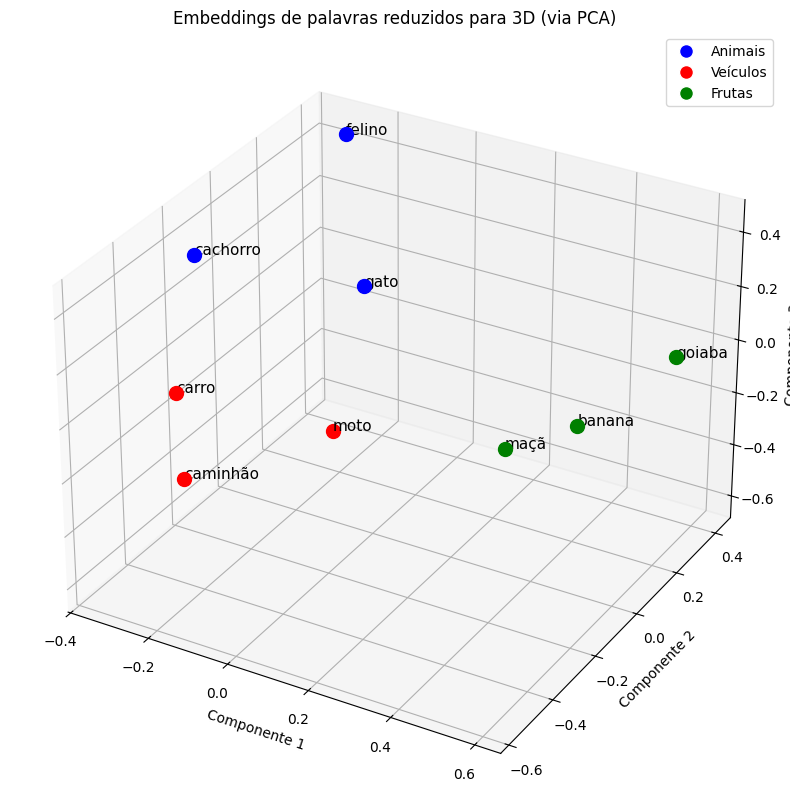

In [9]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pca = PCA(n_components=3)
coords_3d = pca.fit_transform(np.array(embeddings_lista))

cores = ['blue', 'blue', 'blue', 'red', 'red', 'red', 'green', 'green', 'green']

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

for i, palavra in enumerate(palavras):
    x, y, z = coords_3d[i]
    ax.scatter(x, y, z, c=cores[i], s=100)
    ax.text(x, y, z, palavra, fontsize=11)

ax.set_title("Embeddings de palavras reduzidos para 3D (via PCA)")
ax.set_xlabel("Componente 1")
ax.set_ylabel("Componente 2")
ax.set_zlabel("Componente 3")

# Legenda das categorias
legenda_elementos = [
    Line2D([0], [0], marker='o', color='w', label='Animais', markerfacecolor='blue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Veículos', markerfacecolor='red', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Frutas', markerfacecolor='green', markersize=10),
]
ax.legend(handles=legenda_elementos, loc='upper right')

plt.savefig('grafico_embeddings_3d.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
import numpy as np

def distancia_euclidiana(vec1: np.ndarray, vec2: np.ndarray) -> float:
    """Calcula a Distância Euclidiana (norma L2 da diferença) entre dois vetores."""
    return float(np.linalg.norm(vec1 - vec2))

def similaridade_cosseno(vec1: np.ndarray, vec2: np.ndarray) -> float:
    """Calcula a Similaridade de Cosseno entre dois vetores."""
    norm_v1 = np.linalg.norm(vec1)
    norm_v2 = np.linalg.norm(vec2)
    if norm_v1 == 0 or norm_v2 == 0:
        return 0.0
    return float(np.dot(vec1, vec2) / (norm_v1 * norm_v2))

def distancia_cosseno(vec1: np.ndarray, vec2: np.ndarray) -> float:
    """Calcula a Distância de Cosseno (1 - Similaridade de Cosseno)."""
    return float(1.0 - similaridade_cosseno(vec1, vec2))

In [11]:
embedding_a = np.array([1, 0, 0])
embedding_b = np.array([0, 1, 0])
embedding_c = np.array([1, 0, 0])

pares = [
    ("a vs b", embedding_a, embedding_b),
    ("a vs c", embedding_a, embedding_c),
    ("b vs c", embedding_b, embedding_c),
]

for nome, v1, v2 in pares:
    print(f"{nome} -> euclidiana: {distancia_euclidiana(v1, v2):.4f} | "
          f"cosseno: {distancia_cosseno(v1, v2):.4f}")

a vs b -> euclidiana: 1.4142 | cosseno: 1.0000
a vs c -> euclidiana: 0.0000 | cosseno: 0.0000
b vs c -> euclidiana: 1.4142 | cosseno: 1.0000


In [12]:
palavras = ["gato", "felino", "cachorro", "carro", "caminhão", "moto", "banana", "maçã", "goiaba"]
embeddings_palavras, _ = gerar_embeddings_em_lote(palavras)
embeddings_palavras = [np.array(e) for e in embeddings_palavras]

# exemplo: comparar "gato" com todas as outras
idx_gato = palavras.index("gato")
vec_gato = embeddings_palavras[idx_gato]

for i, palavra in enumerate(palavras):
    if palavra == "gato":
        continue
    v = embeddings_palavras[i]
    print(f"gato vs {palavra:10s} -> euclidiana: {distancia_euclidiana(vec_gato, v):.4f} | "
          f"cosseno: {distancia_cosseno(vec_gato, v):.4f}")

gato vs felino     -> euclidiana: 1.1179 | cosseno: 0.6248
gato vs cachorro   -> euclidiana: 1.0931 | cosseno: 0.5974
gato vs carro      -> euclidiana: 1.1397 | cosseno: 0.6495
gato vs caminhão   -> euclidiana: 1.2189 | cosseno: 0.7428
gato vs moto       -> euclidiana: 1.0782 | cosseno: 0.5813
gato vs banana     -> euclidiana: 1.2584 | cosseno: 0.7918
gato vs maçã       -> euclidiana: 1.2614 | cosseno: 0.7955
gato vs goiaba     -> euclidiana: 1.2193 | cosseno: 0.7433


In [13]:
def get_embedding(texto):
    """Wrapper que retorna só o vetor de embedding (sem o objeto de uso)."""
    embedding, _ = gerar_embedding(texto)
    return embedding

In [14]:
import numpy as np
import pandas as pd

frase_ancora = "O cachorro correu no parque e brincou com a bola."

frases_comparacao = [
    ("Similar (mesmo sentido, palavras diferentes)", "Um cão estava correndo no jardim e brincando com seu brinquedo."),
    ("Relacionado (mesmo contexto de animais)", "O gato dormiu na almofada da sala durante toda a tarde."),
    ("Diferente (outro domínio - economia)", "A taxa de juros do banco central subiu dois pontos percentuais."),
    ("Oposto/Negação", "Nenhum animal esteve no parque e o cão permaneceu preso em casa.")
]

# 1. Gerar o embedding da âncora
vec_ancora = np.array(get_embedding(frase_ancora), dtype=np.float32)

# 2. Gerar os embeddings das comparações (desempacotando rótulo e frase)
vecs_comp = []
for rotulo, frase in frases_comparacao:
    vec = get_embedding(frase)
    vecs_comp.append(np.array(vec, dtype=np.float32))

# 3. Montar os resultados
resultados = []
for (rotulo, frase), vec in zip(frases_comparacao, vecs_comp):
    resultados.append({
        "Texto": rotulo,
        "Dist. Euclidiana": round(distancia_euclidiana(vec_ancora, vec), 4),
        "Similaridade Cosseno": round(similaridade_cosseno(vec_ancora, vec), 4),
        "Distância Cosseno": round(distancia_cosseno(vec_ancora, vec), 4)
    })

df_resultados = pd.DataFrame(resultados)
df_resultados

,Texto,Dist. Euclidiana,Similaridade Cosseno,Distância Cosseno
0,"Similar (mesmo sentido, palavras diferentes)",0.8465,0.6417,0.3583
1,Relacionado (mesmo contexto de animais),1.2289,0.2449,0.7551
2,Diferente (outro domínio - economia),1.3641,0.0697,0.9303
3,Oposto/Negação,0.9696,0.5299,0.4701


Busca Semântica Manual

In [15]:
from google.colab import files
uploaded = files.upload()

Saving twitter_algoritmo.md to twitter_algoritmo.md
Saving escrita_academica_ia.md to escrita_academica_ia.md
Saving bioetica_e_ia.md to bioetica_e_ia.md


In [16]:
import os
print(os.listdir('/content'))

['.config', 'escrita_academica_ia.md', 'grafico_embeddings_3d.png', 'twitter_algoritmo.md', 'bioetica_e_ia.md', 'sample_data']


In [17]:
# 1. Ler os arquivos .md e separar linha por linha
arquivos_md = ['twitter_algoritmo.md', 'escrita_academica_ia.md', 'bioetica_e_ia.md']

trechos = []  # cada item: {"texto": ..., "arquivo": ...}

for nome_arquivo in arquivos_md:
    with open(nome_arquivo, 'r', encoding='utf-8') as f:
        linhas = f.readlines()
    for linha in linhas:
        linha_limpa = linha.strip()
        if linha_limpa:  # ignora linhas vazias
            trechos.append({"texto": linha_limpa, "arquivo": nome_arquivo})

print(f"Total de linhas não-vazias lidas: {len(trechos)}")
print(f"\nExemplo de trecho:")
print(trechos[0])

Total de linhas não-vazias lidas: 507

Exemplo de trecho:
{'texto': 'ARTIGOS                                                            E-ISSN: 2176-6665', 'arquivo': 'twitter_algoritmo.md'}


In [18]:
# 2. Gerar embeddings para todas as linhas (em lotes de 50, para não estourar limite da API)
import time

def gerar_embeddings_em_blocos(lista_textos, tamanho_bloco=50):
    todos_embeddings = []
    total_tokens = 0
    for i in range(0, len(lista_textos), tamanho_bloco):
        bloco = lista_textos[i:i + tamanho_bloco]
        embs, tokens = gerar_embeddings_em_lote(bloco)
        todos_embeddings.extend(embs)
        total_tokens += tokens
        print(f"Bloco {i}-{i+len(bloco)} processado ({len(todos_embeddings)}/{len(lista_textos)})")
    return todos_embeddings, total_tokens

textos_trechos = [t["texto"] for t in trechos]
embeddings_trechos, tokens_totais = gerar_embeddings_em_blocos(textos_trechos, tamanho_bloco=50)

print(f"\n✅ Total de embeddings gerados: {len(embeddings_trechos)}")
print(f"Total de tokens gastos: {tokens_totais}")

Bloco 0-50 processado (50/507)
Bloco 50-100 processado (100/507)
Bloco 100-150 processado (150/507)
Bloco 150-200 processado (200/507)
Bloco 200-250 processado (250/507)
Bloco 250-300 processado (300/507)
Bloco 300-350 processado (350/507)
Bloco 350-400 processado (400/507)
Bloco 400-450 processado (450/507)
Bloco 450-500 processado (500/507)
Bloco 500-507 processado (507/507)

✅ Total de embeddings gerados: 507
Total de tokens gastos: 40100


In [19]:
# 3-6. Definir query, calcular similaridade contra cada trecho, retornar TOP 3
import numpy as np
import pandas as pd

def buscar_top_k(query, trechos, embeddings_trechos, k=3):
    """
    Busca semântica simples: compara o embedding da query contra
    todos os embeddings dos trechos e retorna os top k mais similares.
    """
    vec_query = np.array(get_embedding(query), dtype=np.float32)

    resultados = []
    for trecho, emb in zip(trechos, embeddings_trechos):
        vec_trecho = np.array(emb, dtype=np.float32)
        score = similaridade_cosseno(vec_query, vec_trecho)
        resultados.append({
            "score": round(score, 4),
            "texto": trecho["texto"],
            "arquivo": trecho["arquivo"]
        })

    resultados.sort(key=lambda x: x["score"], reverse=True)
    return resultados[:k]

# Exemplo de busca
query = "O que é bioética e por que ela é importante na inteligência artificial?"
top3 = buscar_top_k(query, trechos, embeddings_trechos, k=3)

df_top3 = pd.DataFrame(top3)
df_top3

,score,texto,arquivo
0,0.5876,Palavras-chave: Bioética. Inteligência artific...,bioetica_e_ia.md
1,0.5760,Palabras clave: Bioética. Inteligencia artific...,bioetica_e_ia.md
2,0.5658,Keywords: Bioethics. Artificial intelligence. ...,bioetica_e_ia.md


In [20]:
def ler_paragrafos(nome_arquivo, min_caracteres=80):
    with open(nome_arquivo, 'r', encoding='utf-8') as f:
        conteudo = f.read()
    # separa por linha(s) em branco = parágrafos
    blocos = conteudo.split('\n\n')
    # filtra blocos muito curtos (números de página, marcadores de imagem, títulos soltos)
    paragrafos = [b.strip() for b in blocos if len(b.strip()) >= min_caracteres]
    return paragrafos

trechos_paragrafo = []
for nome_arquivo in arquivos_md:
    paragrafos = ler_paragrafos(nome_arquivo)
    for p in paragrafos:
        trechos_paragrafo.append({"texto": p, "arquivo": nome_arquivo})

print(f"Total de parágrafos lidos: {len(trechos_paragrafo)}")
print(f"\nExemplo de parágrafo:")
print(trechos_paragrafo[0]["texto"][:300], "...")

Total de parágrafos lidos: 268

Exemplo de parágrafo:
ARTIGOS                                                            E-ISSN: 2176-6665 ...


In [21]:
# Gerar embeddings para os parágrafos
textos_paragrafo = [t["texto"] for t in trechos_paragrafo]
embeddings_paragrafo, tokens_paragrafo = gerar_embeddings_em_blocos(textos_paragrafo, tamanho_bloco=50)

print(f"\n✅ Total de embeddings gerados: {len(embeddings_paragrafo)}")
print(f"Total de tokens gastos: {tokens_paragrafo}")

Bloco 0-50 processado (50/268)
Bloco 50-100 processado (100/268)
Bloco 100-150 processado (150/268)
Bloco 150-200 processado (200/268)
Bloco 200-250 processado (250/268)
Bloco 250-268 processado (268/268)

✅ Total de embeddings gerados: 268
Total de tokens gastos: 37955


In [22]:
# Repetir a busca com a mesma query, agora por parágrafo
query = "O que é bioética e por que ela é importante na inteligência artificial?"
top3_paragrafo = buscar_top_k(query, trechos_paragrafo, embeddings_paragrafo, k=3)

df_top3_paragrafo = pd.DataFrame(top3_paragrafo)
df_top3_paragrafo

,score,texto,arquivo
0,0.5876,Palavras-chave: Bioética. Inteligência artific...,bioetica_e_ia.md
1,0.5760,Palabras clave: Bioética. Inteligencia artific...,bioetica_e_ia.md
2,0.5658,Keywords: Bioethics. Artificial intelligence. ...,bioetica_e_ia.md


In [23]:
# Testar com uma query voltada ao conteúdo do corpo do texto (não metadados)
query2 = "Como a inteligência artificial pode ajudar no diagnóstico médico?"

print("=== Busca por LINHA ===")
top3_linha_q2 = buscar_top_k(query2, trechos, embeddings_trechos, k=3)
display(pd.DataFrame(top3_linha_q2))

print("\n=== Busca por PARÁGRAFO ===")
top3_paragrafo_q2 = buscar_top_k(query2, trechos_paragrafo, embeddings_paragrafo, k=3)
display(pd.DataFrame(top3_paragrafo_q2))

=== Busca por LINHA ===


,score,texto,arquivo
0,0.5516,A introdução da inteligência artificial (IA) n...,bioetica_e_ia.md
1,0.5013,O avanço da inteligência artificial tem transf...,bioetica_e_ia.md
2,0.4782,A inteligência artificial representa uma das t...,bioetica_e_ia.md



=== Busca por PARÁGRAFO ===


,score,texto,arquivo
0,0.5516,A introdução da inteligência artificial (IA) n...,bioetica_e_ia.md
1,0.5013,O avanço da inteligência artificial tem transf...,bioetica_e_ia.md
2,0.4782,A inteligência artificial representa uma das t...,bioetica_e_ia.md


In [24]:
# 8. Dividir por capítulo/seção (marcado por ## no Markdown)
import re

def ler_capitulos(nome_arquivo):
    with open(nome_arquivo, 'r', encoding='utf-8') as f:
        conteudo = f.read()
    # divide o texto sempre que encontrar um título de seção "## "
    partes = re.split(r'\n##\s+', conteudo)
    capitulos = []
    for i, parte in enumerate(partes):
        texto = parte.strip()
        if len(texto) >= 100:  # ignora capítulos vazios/curtos demais
            capitulos.append(texto)
    return capitulos

trechos_capitulo = []
for nome_arquivo in arquivos_md:
    capitulos = ler_capitulos(nome_arquivo)
    for c in capitulos:
        trechos_capitulo.append({"texto": c, "arquivo": nome_arquivo})

print(f"Total de capítulos/seções lidos: {len(trechos_capitulo)}")
print(f"\nExemplo de capítulo (primeiros 300 caracteres):")
print(trechos_capitulo[0]["texto"][:300], "...")

Total de capítulos/seções lidos: 58

Exemplo de capítulo (primeiros 300 caracteres):
DOI: 10.5433/2176-6665.2025v30e52669

Recebido em 30/03/2025; aprovado em 18/096/2025; publicado em 10/11/2025. ...


In [25]:
# Gerar embeddings para os capítulos
textos_capitulo = [t["texto"] for t in trechos_capitulo]
embeddings_capitulo, tokens_capitulo = gerar_embeddings_em_blocos(textos_capitulo, tamanho_bloco=50)

print(f"\n✅ Total de embeddings gerados: {len(embeddings_capitulo)}")
print(f"Total de tokens gastos: {tokens_capitulo}")

Bloco 0-50 processado (50/58)
Bloco 50-58 processado (58/58)

✅ Total de embeddings gerados: 58
Total de tokens gastos: 39225


In [26]:
# Comparar os 3 níveis de granularidade com a mesma query
print("=== Busca por LINHA ===")
display(pd.DataFrame(buscar_top_k(query2, trechos, embeddings_trechos, k=3)))

print("\n=== Busca por PARÁGRAFO ===")
display(pd.DataFrame(buscar_top_k(query2, trechos_paragrafo, embeddings_paragrafo, k=3)))

print("\n=== Busca por CAPÍTULO ===")
top3_capitulo_q2 = buscar_top_k(query2, trechos_capitulo, embeddings_capitulo, k=3)
for r in top3_capitulo_q2:
    print(f"\nScore: {r['score']} | Arquivo: {r['arquivo']}")
    print(f"Texto: {r['texto'][:400]}...")

=== Busca por LINHA ===


,score,texto,arquivo
0,0.5516,A introdução da inteligência artificial (IA) n...,bioetica_e_ia.md
1,0.5013,O avanço da inteligência artificial tem transf...,bioetica_e_ia.md
2,0.4782,A inteligência artificial representa uma das t...,bioetica_e_ia.md



=== Busca por PARÁGRAFO ===


,score,texto,arquivo
0,0.5516,A introdução da inteligência artificial (IA) n...,bioetica_e_ia.md
1,0.5013,O avanço da inteligência artificial tem transf...,bioetica_e_ia.md
2,0.4782,A inteligência artificial representa uma das t...,bioetica_e_ia.md



=== Busca por CAPÍTULO ===

Score: 0.5068 | Arquivo: bioetica_e_ia.md
Texto: Resumo

O avanço da inteligência artificial tem transformado profundamente a prática médica. De sistemas de apoio à decisão clínica a algoritmos de triagem e diagnóstico, a inteligência artificial tem demons -trado potencial para diagnósticos precoces, terapias personalizadas, otimização de recursos, redução de erros e ampliação do acesso a cuidados especializados. Contudo, essa revolução tecnológ...

Score: 0.4255 | Arquivo: bioetica_e_ia.md
Texto: Entre el algoritmo y el Juramento Hipocrático: bioética en la era de la inteligencia artificial

El avance de la inteligencia artificial ha transformado profundamente la práctica médica. Desde sistemas de apoyo a la decisión clínica hasta algoritmos de triaje y diagnóstico, la inteligencia artificial ha demostrado potencial para diagnósticos precoces, terapias personalizadas, optimización de recur...

Score: 0.415 | Arquivo: bioetica_e_ia.md
Texto: Between the alg

In [27]:
# Diagnóstico: ver como está a estrutura real de um dos arquivos
with open('bioetica_e_ia.md', 'r', encoding='utf-8') as f:
    conteudo = f.read()

print(repr(conteudo[:500]))

'273\n\n<!-- image -->\n\n## Entre o algoritmo e o Juramento de Hipócrates: bioética na era da inteligência artificial\n\nJuracy Barbosa dos Santos 1 , Guilhermina Rego 1 , Rui Nunes 1\n\n1. Faculdade de Medicina da Universidade do Porto, Porto, Portugal.\n\n## Resumo\n\nO avanço da inteligência artificial tem transformado profundamente a prática médica. De sistemas de apoio à decisão clínica a algoritmos de triagem e diagnóstico, a inteligência artificial tem demons -trado potencial para diagnósticos precoc'


## Usando `langchain-text-splitters` (biblioteca oficial)


In [28]:
!pip install -U langchain-text-splitters tiktoken -q


In [29]:
from langchain_text_splitters import RecursiveCharacterTextSplitter


In [30]:
from google.colab import files
uploaded = files.upload()

Saving attention_is_all_you_need.pdf to attention_is_all_you_need.pdf
Saving bert_pretraining.pdf to bert_pretraining.pdf
Saving bioetica_e_ia.pdf to bioetica_e_ia.pdf
Saving escrita_academica_ia.pdf to escrita_academica_ia.pdf
Saving gpt3_language_models.pdf to gpt3_language_models.pdf
Saving gpt4_technical_report.pdf to gpt4_technical_report.pdf
Saving instruct_gpt.pdf to instruct_gpt.pdf
Saving llama_foundation_models.pdf to llama_foundation_models.pdf
Saving lora_low_rank_adaptation.pdf to lora_low_rank_adaptation.pdf
Saving retrieval_augmented_generation.pdf to retrieval_augmented_generation.pdf
Saving scaling_laws_llm.pdf to scaling_laws_llm.pdf
Saving twitter_algoritmo.pdf to twitter_algoritmo.pdf


In [31]:
import os
print(os.listdir('/content'))

['.config', 'scaling_laws_llm.pdf', 'twitter_algoritmo.pdf', 'bioetica_e_ia.pdf', 'escrita_academica_ia.md', 'escrita_academica_ia.pdf', 'llama_foundation_models.pdf', 'grafico_embeddings_3d.png', 'bert_pretraining.pdf', 'gpt3_language_models.pdf', 'instruct_gpt.pdf', 'gpt4_technical_report.pdf', 'twitter_algoritmo.md', 'retrieval_augmented_generation.pdf', 'lora_low_rank_adaptation.pdf', 'bioetica_e_ia.md', 'attention_is_all_you_need.pdf', 'sample_data']


In [32]:
!pip install -U pymupdf4llm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.4/176.4 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 79.1 MB/s eta 0:00:00


In [33]:
import os

# Lista apenas os arquivos PDF (ignora .md e .png residuais)
pdfs = [f for f in os.listdir('/content') if f.endswith('.pdf')]
print(f"Total de PDFs encontrados: {len(pdfs)}")
for pdf in pdfs:
    print(f"  - {pdf}")

Total de PDFs encontrados: 12
  - scaling_laws_llm.pdf
  - twitter_algoritmo.pdf
  - bioetica_e_ia.pdf
  - escrita_academica_ia.pdf
  - llama_foundation_models.pdf
  - bert_pretraining.pdf
  - gpt3_language_models.pdf
  - instruct_gpt.pdf
  - gpt4_technical_report.pdf
  - retrieval_augmented_generation.pdf
  - lora_low_rank_adaptation.pdf
  - attention_is_all_you_need.pdf


In [34]:
import pymupdf4llm

# Teste de extração com um PDF pequeno primeiro
markdown_teste = pymupdf4llm.to_markdown("bioetica_e_ia.pdf")

print(f"Tamanho do markdown gerado: {len(markdown_teste)} caracteres")
print("\n--- Primeiros 1000 caracteres ---\n")
print(markdown_teste[:1000])


=== Document parser messages ===
Using Tesseract for OCR processing.
Tamanho do markdown gerado: 53620 caracteres

--- Primeiros 1000 caracteres ---

Revista Bioética 

Print version ISSN 1983-8042 | On-line version ISSN 1983-8034 

Rev. Bioét. vol.34 Brasília 2026 

# **Entre o algoritmo e o Juramento de Hipócrates: bioética na era da inteligência artificial** 

_Juracy Barbosa dos Santos_<sup>1</sup> _, Guilhermina Rego_<sup>1</sup> _, Rui Nunes_<sup>1</sup> 

**1.** Faculdade de Medicina da Universidade do Porto, Porto, Portugal. 

### **Resumo** 

O avanço da inteligência artificial tem transformado profundamente a prática médica. De sistemas de apoio à decisão clínica a algoritmos de triagem e diagnóstico, a inteligência artificial tem demonstrado potencial para diagnósticos precoces, terapias personalizadas, otimização de recursos, redução de erros e ampliação do acesso a cuidados especializados. Contudo, essa revolução tecnológica impõe desafios éticos significativos aos princí

In [38]:
# Salvar o markdown extraído em arquivo
with open("bioetica_e_ia_extraido.md", "w", encoding="utf-8") as f:
    f.write(markdown_teste)

print("Markdown salvo com sucesso!")

# Teste com um PDF técnico (provavelmente tem tabelas)
markdown_gpt3 = pymupdf4llm.to_markdown("gpt3_language_models.pdf")
print(f"\nTamanho do markdown do GPT-3: {len(markdown_gpt3)} caracteres")

# Procurar por evidência de tabela no markdown (geralmente contém "|")
tem_tabela = "|" in markdown_gpt3
print(f"Contém sintaxe de tabela Markdown (|): {tem_tabela}")

Markdown salvo com sucesso!

=== Document parser messages ===
Using Tesseract for OCR processing.
OCR on page.number=2/3.
OCR on page.number=3/4.
OCR on page.number=4/5.
OCR on page.number=6/7.
OCR on page.number=8/9.
OCR on page.number=10/11.
OCR on page.number=11/12.
OCR on page.number=13/14.
OCR on page.number=14/15.
OCR on page.number=15/16.
OCR on page.number=16/17.
OCR on page.number=18/19.
OCR on page.number=19/20.
OCR on page.number=20/21.
OCR on page.number=21/22.
OCR on page.number=23/24.
OCR on page.number=24/25.
OCR on page.number=26/27.
OCR on page.number=30/31.
OCR on page.number=31/32.
OCR on page.number=37/38.
OCR on page.number=46/47.
OCR on page.number=63/64.
OCR on page.number=64/65.
OCR on page.number=65/66.
OCR on page.number=66/67.

Tamanho do markdown do GPT-3: 263415 caracteres
Contém sintaxe de tabela Markdown (|): True


In [39]:
# Localizar e mostrar um trecho que contenha tabela
indice_tabela = markdown_gpt3.find("|")
print(markdown_gpt3[indice_tabela-200:indice_tabela+800])

In [40]:
trecho = markdown_gpt3[indice_tabela-200:indice_tabela+800]
for linha in trecho.split('\n'):
    print(linha)

In [41]:
with open("trecho_tabela.txt", "w", encoding="utf-8") as f:
    f.write(trecho)
print("Arquivo salvo, abra trecho_tabela.txt no painel de Arquivos à esquerda")

Arquivo salvo, abra trecho_tabela.txt no painel de Arquivos à esquerda


In [42]:
# Buscar todas as posições onde aparece "|" e pegar uma ocorrência mais "sólida"
posicoes = [i for i in range(len(markdown_gpt3)) if markdown_gpt3[i] == "|"]
print(f"Total de ocorrências de '|': {len(posicoes)}")
print(f"Primeiras 5 posições: {posicoes[:5]}")

# Pega uma posição bem no meio da lista, mais provável de estar dentro de uma tabela de verdade
indice_tabela = posicoes[len(posicoes)//2]
inicio = max(0, indice_tabela - 200)
fim = indice_tabela + 800

trecho = markdown_gpt3[inicio:fim]
print("\n--- Trecho com tabela ---\n")
print(trecho)

Total de ocorrências de '|': 3251
Primeiras 5 posições: [44, 59, 96, 133, 193]

--- Trecho com tabela ---

0|2.25E+20|125|300|6|3|2|1.0|
|GPT-3 Medium|7.42E+00|6.41E+20|356|300|6|3|2|1.0|
|GPT-3 Large|1.58E+01|1.37E+21|760|300|6|3|2|1.0|
|GPT-3 XL|2.75E+01|2.38E+21|1,320|300|6|3|2|1.0|
|GPT-3 2.7B|5.52E+01|4.77E+21|2,650|300|6|3|2|1.0|
|GPT-3 6.7B|1.39E+02|1.20E+22|6,660|300|6|3|2|1.0|
|GPT-3 13B|2.68E+02|2.31E+22|12,850|300|6|3|2|1.0|
|GPT-3 175B|3.64E+03|3.14E+23|174,600|300|6|3|2|1.0|



**Table D.1:** Starting from the right hand side and moving left, we begin with the number of training tokens that each model was trained with. Next we note that since T5 uses an encoder-decoder model, only half of the parameters are active for each token during a forward or backwards pass. We then note that each token is involved in a single addition and a single multiply for each active parameter in the forward pass (ignoring attention). Then we add a multiplier of 3x to account for the backwards 

In [43]:
import time

pdfs = [f for f in os.listdir('/content') if f.endswith('.pdf')]
markdowns = {}  # nome_documento -> texto markdown

for pdf in pdfs:
    print(f"Processando: {pdf}...")
    inicio = time.time()
    try:
        md_texto = pymupdf4llm.to_markdown(pdf)
        markdowns[pdf] = md_texto

        # Salva também como arquivo .md
        nome_md = pdf.replace('.pdf', '.md')
        with open(nome_md, 'w', encoding='utf-8') as f:
            f.write(md_texto)

        duracao = time.time() - inicio
        print(f"  ✅ {len(md_texto)} caracteres extraídos em {duracao:.1f}s")
    except Exception as e:
        print(f"  ❌ Erro ao processar {pdf}: {e}")

print(f"\n✅ Total de documentos processados: {len(markdowns)}/{len(pdfs)}")

Processando: scaling_laws_llm.pdf...

=== Document parser messages ===
Using Tesseract for OCR processing.
OCR on page.number=2/3.
OCR on page.number=3/4.
OCR on page.number=4/5.
OCR on page.number=6/7.
OCR on page.number=8/9.
OCR on page.number=10/11.
OCR on page.number=11/12.
OCR on page.number=13/14.
OCR on page.number=14/15.
OCR on page.number=15/16.
OCR on page.number=16/17.
OCR on page.number=18/19.
OCR on page.number=19/20.
OCR on page.number=20/21.
OCR on page.number=21/22.
OCR on page.number=23/24.
OCR on page.number=24/25.
OCR on page.number=26/27.
OCR on page.number=30/31.
OCR on page.number=31/32.
OCR on page.number=37/38.
OCR on page.number=46/47.
OCR on page.number=63/64.
OCR on page.number=64/65.
OCR on page.number=65/66.
OCR on page.number=66/67.
  ✅ 95514 caracteres extraídos em 20.2s
Processando: twitter_algoritmo.pdf...

=== Document parser messages ===
Using Tesseract for OCR processing.
OCR on page.number=11/12.
OCR on page.number=12/13.
OCR on page.number=13/14.
 

In [44]:
from langchain_text_splitters import CharacterTextSplitter

# Carregar os 3 documentos-base (já extraídos como .md)
docs_base = ['bioetica_e_ia.md', 'escrita_academica_ia.md', 'twitter_algoritmo.md']

textos_base = {}
for nome in docs_base:
    with open(nome, 'r', encoding='utf-8') as f:
        textos_base[nome] = f.read()
    print(f"{nome}: {len(textos_base[nome])} caracteres")

bioetica_e_ia.md: 53620 caracteres
escrita_academica_ia.md: 46885 caracteres
twitter_algoritmo.md: 58981 caracteres


In [45]:
from langchain_text_splitters import CharacterTextSplitter

# Configurações dos Testes 1 a 4 (fixo, sem overlap)
configs_1_a_4 = [
    {"test_id": 1, "chunk_size": 200, "chunk_overlap": 0},
    {"test_id": 2, "chunk_size": 500, "chunk_overlap": 0},
    {"test_id": 3, "chunk_size": 1000, "chunk_overlap": 0},
    {"test_id": 4, "chunk_size": 2000, "chunk_overlap": 0},
]

resultados_chunking = {}  # (nome_doc, test_id) -> lista de chunks

for nome_doc, texto in textos_base.items():
    for config in configs_1_a_4:
        splitter = CharacterTextSplitter(
            separator="",  # divide puramente por caracteres, ignora estrutura
            chunk_size=config["chunk_size"],
            chunk_overlap=config["chunk_overlap"]
        )
        chunks = splitter.split_text(texto)
        resultados_chunking[(nome_doc, config["test_id"])] = chunks

# Conferir resultado pro documento bioetica_e_ia.md
for test_id in [1, 2, 3, 4]:
    chunks = resultados_chunking[("bioetica_e_ia.md", test_id)]
    tamanhos = [len(c) for c in chunks]
    print(f"Teste {test_id} (chunk_size={configs_1_a_4[test_id-1]['chunk_size']}):")
    print(f"  Total de chunks: {len(chunks)}")
    print(f"  Tamanho médio: {sum(tamanhos)/len(tamanhos):.1f}")
    print(f"  Tamanho mín/máx: {min(tamanhos)}/{max(tamanhos)}")
    print()

Teste 1 (chunk_size=200):
  Total de chunks: 269
  Tamanho médio: 199.0
  Tamanho mín/máx: 17/200

Teste 2 (chunk_size=500):
  Total de chunks: 108
  Tamanho médio: 496.2
  Tamanho mín/máx: 117/500

Teste 3 (chunk_size=1000):
  Total de chunks: 54
  Tamanho médio: 992.7
  Tamanho mín/máx: 617/1000

Teste 4 (chunk_size=2000):
  Total de chunks: 27
  Tamanho médio: 1985.6
  Tamanho mín/máx: 1617/2000



In [46]:
# Configurações dos Testes 5 e 6 (fixo, com overlap)
configs_5_e_6 = [
    {"test_id": 5, "chunk_size": 500, "chunk_overlap": 50},
    {"test_id": 6, "chunk_size": 500, "chunk_overlap": 200},
]

for nome_doc, texto in textos_base.items():
    for config in configs_5_e_6:
        splitter = CharacterTextSplitter(
            separator="",
            chunk_size=config["chunk_size"],
            chunk_overlap=config["chunk_overlap"]
        )
        chunks = splitter.split_text(texto)
        resultados_chunking[(nome_doc, config["test_id"])] = chunks

# Conferir resultado pro documento bioetica_e_ia.md
for test_id in [5, 6]:
    chunks = resultados_chunking[("bioetica_e_ia.md", test_id)]
    tamanhos = [len(c) for c in chunks]
    config = configs_5_e_6[test_id - 5]
    print(f"Teste {test_id} (chunk_size={config['chunk_size']}, overlap={config['chunk_overlap']}):")
    print(f"  Total de chunks: {len(chunks)}")
    print(f"  Tamanho médio: {sum(tamanhos)/len(tamanhos):.1f}")
    print(f"  Tamanho mín/máx: {min(tamanhos)}/{max(tamanhos)}")

    # Calcular percentual de overlap real (comparando chunk[i] final com chunk[i+1] início)
    sobreposicoes = 0
    for i in range(len(chunks) - 1):
        fim_atual = chunks[i][-config['chunk_overlap']:] if config['chunk_overlap'] > 0 else ""
        inicio_proximo = chunks[i+1][:config['chunk_overlap']] if config['chunk_overlap'] > 0 else ""

Teste 5 (chunk_size=500, overlap=50):
  Total de chunks: 120
  Tamanho médio: 496.1
  Tamanho mín/máx: 67/500
Teste 6 (chunk_size=500, overlap=200):
  Total de chunks: 179
  Tamanho médio: 498.1
  Tamanho mín/máx: 216/500


In [47]:
# Teste 7 - Por parágrafo (separador = quebra de linha dupla)
splitter_paragrafo = CharacterTextSplitter(
    separator="\n\n",
    chunk_size=100000,  # bem grande, pra não cortar por tamanho, só por parágrafo
    chunk_overlap=0
)

for nome_doc, texto in textos_base.items():
    chunks = splitter_paragrafo.split_text(texto)
    resultados_chunking[(nome_doc, 7)] = chunks

# Conferir resultado
chunks = resultados_chunking[("bioetica_e_ia.md", 7)]
tamanhos = [len(c) for c in chunks]
print(f"Teste 7 (por parágrafo):")
print(f"  Total de chunks: {len(chunks)}")
print(f"  Tamanho médio: {sum(tamanhos)/len(tamanhos):.1f}")
print(f"  Tamanho mín/máx: {min(tamanhos)}/{max(tamanhos)}")
print(f"\n  Exemplo de chunk (primeiro):")
print(f"  {chunks[0][:300]}")

Teste 7 (por parágrafo):
  Total de chunks: 1
  Tamanho médio: 53617.0
  Tamanho mín/máx: 53617/53617

  Exemplo de chunk (primeiro):
  Revista Bioética 

Print version ISSN 1983-8042 | On-line version ISSN 1983-8034 

Rev. Bioét. vol.34 Brasília 2026 

# **Entre o algoritmo e o Juramento de Hipócrates: bioética na era da inteligência artificial** 

_Juracy Barbosa dos Santos_<sup>1</sup> _, Guilhermina Rego_<sup>1</sup> _, Rui Nune


In [48]:
# Investigar como as quebras de linha aparecem no texto
texto_teste = textos_base["bioetica_e_ia.md"]

print("Contém '\\n\\n'?", "\n\n" in texto_teste)
print("Quantidade de '\\n\\n':", texto_teste.count("\n\n"))
print("Quantidade de '\\n':", texto_teste.count("\n"))

# Mostrar os primeiros 300 caracteres em repr() pra ver as quebras exatas
print("\n--- repr dos primeiros 300 caracteres ---")
print(repr(texto_teste[:300]))

Contém '\n\n'? True
Quantidade de '\n\n': 215
Quantidade de '\n': 430

--- repr dos primeiros 300 caracteres ---
'Revista Bioética \n\nPrint version ISSN 1983-8042 | On-line version ISSN 1983-8034 \n\nRev. Bioét. vol.34 Brasília 2026 \n\n# **Entre o algoritmo e o Juramento de Hipócrates: bioética na era da inteligência artificial** \n\n_Juracy Barbosa dos Santos_<sup>1</sup> _, Guilhermina Rego_<sup>1</sup> _, Rui Nune'


In [49]:
# Teste 7 - Por parágrafo (versão corrigida, sem merge automático)
def dividir_por_paragrafo(texto):
    partes = texto.split("\n\n")
    return [p.strip() for p in partes if p.strip()]  # remove vazios

for nome_doc, texto in textos_base.items():
    chunks = dividir_por_paragrafo(texto)
    resultados_chunking[(nome_doc, 7)] = chunks

# Conferir resultado
chunks = resultados_chunking[("bioetica_e_ia.md", 7)]
tamanhos = [len(c) for c in chunks]
print(f"Teste 7 (por parágrafo) — CORRIGIDO:")
print(f"  Total de chunks: {len(chunks)}")
print(f"  Tamanho médio: {sum(tamanhos)/len(tamanhos):.1f}")
print(f"  Tamanho mín/máx: {min(tamanhos)}/{max(tamanhos)}")
print(f"\n  Exemplo de chunk (primeiro):")
print(f"  {chunks[0][:300]}")

Teste 7 (por parágrafo) — CORRIGIDO:
  Total de chunks: 215
  Tamanho médio: 246.4
  Tamanho mín/máx: 3/1375

  Exemplo de chunk (primeiro):
  Revista Bioética


In [50]:
import re

def dividir_por_sentencas_agrupadas(texto, sentencas_por_chunk=3):
    # Divide por pontuação de fim de frase (. ! ?), mantendo o padrão simples
    sentencas = re.split(r'(?<=[.!?])\s+', texto)
    sentencas = [s.strip() for s in sentencas if s.strip()]

    chunks = []
    for i in range(0, len(sentencas), sentencas_por_chunk):
        grupo = sentencas[i:i + sentencas_por_chunk]
        chunks.append(" ".join(grupo))
    return chunks

for nome_doc, texto in textos_base.items():
    chunks = dividir_por_sentencas_agrupadas(texto, sentencas_por_chunk=3)
    resultados_chunking[(nome_doc, 8)] = chunks

# Conferir resultado
chunks = resultados_chunking[("bioetica_e_ia.md", 8)]
tamanhos = [len(c) for c in chunks]
print(f"Teste 8 (sentenças agrupadas em 3):")
print(f"  Total de chunks: {len(chunks)}")
print(f"  Tamanho médio: {sum(tamanhos)/len(tamanhos):.1f}")
print(f"  Tamanho mín/máx: {min(tamanhos)}/{max(tamanhos)}")
print(f"\n  Exemplo de chunk (primeiro):")
print(f"  {chunks[0][:400]}")

Teste 8 (sentenças agrupadas em 3):
  Total de chunks: 135
  Tamanho médio: 394.8
  Tamanho mín/máx: 53/1116

  Exemplo de chunk (primeiro):
  Revista Bioética 

Print version ISSN 1983-8042 | On-line version ISSN 1983-8034 

Rev. Bioét. vol.34 Brasília 2026 

# **Entre o algoritmo e o Juramento de Hipócrates: bioética na era da inteligência artificial** 

_Juracy Barbosa dos Santos_<sup>1</sup> _, Guilhermina Rego_<sup>1</sup> _, Rui Nunes_<sup>1</sup> 

**1.** Faculdade de Medicina da Universidade do Porto, Porto, Portugal.


In [51]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Teste 9 - Recursive, com separadores hierárquicos
splitter_recursivo = RecursiveCharacterTextSplitter(
    separators=["\n\n", "\n", " ", ""],  # tenta nessa ordem
    chunk_size=500,
    chunk_overlap=50
)

for nome_doc, texto in textos_base.items():
    chunks = splitter_recursivo.split_text(texto)
    resultados_chunking[(nome_doc, 9)] = chunks

# Conferir resultado
chunks = resultados_chunking[("bioetica_e_ia.md", 9)]
tamanhos = [len(c) for c in chunks]
print(f"Teste 9 (Recursive, chunk_size=500, overlap=50):")
print(f"  Total de chunks: {len(chunks)}")
print(f"  Tamanho médio: {sum(tamanhos)/len(tamanhos):.1f}")
print(f"  Tamanho mín/máx: {min(tamanhos)}/{max(tamanhos)}")
print(f"\n  Exemplo de chunk (primeiro):")
print(f"  {chunks[0][:400]}")

Teste 9 (Recursive, chunk_size=500, overlap=50):
  Total de chunks: 152
  Tamanho médio: 361.8
  Tamanho mín/máx: 16/499

  Exemplo de chunk (primeiro):
  Revista Bioética 

Print version ISSN 1983-8042 | On-line version ISSN 1983-8034 

Rev. Bioét. vol.34 Brasília 2026 

# **Entre o algoritmo e o Juramento de Hipócrates: bioética na era da inteligência artificial** 

_Juracy Barbosa dos Santos_<sup>1</sup> _, Guilhermina Rego_<sup>1</sup> _, Rui Nunes_<sup>1</sup> 

**1.** Faculdade de Medicina da Universidade do Porto, Porto, Portugal. 

### **Res


In [53]:
from langchain_text_splitters import MarkdownHeaderTextSplitter

# Teste 10 - Markdown Splitter (por headings)
headers_a_dividir = [
    ("#", "titulo_principal"),
    ("##", "secao"),
    ("###", "subsecao"),
]

splitter_markdown = MarkdownHeaderTextSplitter(headers_to_split_on=headers_a_dividir)

for nome_doc, texto in textos_base.items():
    docs = splitter_markdown.split_text(texto)
    # docs é uma lista de objetos Document (com .page_content e .metadata)
    chunks = [d.page_content for d in docs]
    resultados_chunking[(nome_doc, 10)] = chunks

# Conferir resultado
docs_bioetica = splitter_markdown.split_text(textos_base["bioetica_e_ia.md"])
tamanhos = [len(d.page_content) for d in docs_bioetica]
print(f"Teste 10 (Markdown Splitter, por headings):")
print(f"  Total de chunks: {len(docs_bioetica)}")
print(f"  Tamanho médio: {sum(tamanhos)/len(tamanhos):.1f}")
print(f"  Tamanho mín/máx: {min(tamanhos)}/{max(tamanhos)}")
print(f"\n  Exemplo de chunk (primeiro) com metadados:")
print(f"  Metadados: {docs_bioetica[0].metadata}")
print(f"  Conteúdo: {docs_bioetica[0].page_content[:300]}")

Teste 10 (Markdown Splitter, por headings):
  Total de chunks: 19
  Tamanho médio: 2770.7
  Tamanho mín/máx: 115/8779

  Exemplo de chunk (primeiro) com metadados:
  Metadados: {}
  Conteúdo: Revista Bioética  
Print version ISSN 1983-8042 | On-line version ISSN 1983-8034  
Rev. Bioét. vol.34 Brasília 2026


In [54]:
# Função de embeddings em blocos, já criada na Aula 03 — vamos recriar aqui por segurança
def gerar_embeddings_em_lote(lista_textos):
    response = client.embeddings.create(
        model="nvidia/nemotron-3-embed-1b:free",
        input=lista_textos,
        encoding_format="float"
    )
    embeddings = [item.embedding for item in response.data]
    return embeddings, response.usage.total_tokens


def gerar_embeddings_em_blocos(lista_textos, tamanho_bloco=50):
    todos_embeddings = []
    total_tokens = 0
    for i in range(0, len(lista_textos), tamanho_bloco):
        bloco = lista_textos[i:i + tamanho_bloco]
        embs, tokens = gerar_embeddings_em_lote(bloco)
        todos_embeddings.extend(embs)
        total_tokens += tokens
    return todos_embeddings, total_tokens


# Verificar se o client já existe (da Aula 03); se não, recriar
try:
    client
    print("Client já existe, reaproveitando.")
except NameError:
    from google.colab import userdata
    from openai import OpenAI
    client = OpenAI(
        api_key=userdata.get('OPENAI_API_KEY'),
        base_url="https://openrouter.ai/api/v1"
    )
    print("Client recriado.")

Client já existe, reaproveitando.


In [55]:
# Contar total de chunks que serão processados
total_chunks_geral = sum(len(chunks) for chunks in resultados_chunking.values())
print(f"Total de combinações (documento x teste): {len(resultados_chunking)}")
print(f"Total de chunks a gerar embedding: {total_chunks_geral}")

# Detalhamento por teste (somando os 3 documentos)
from collections import defaultdict
contagem_por_teste = defaultdict(int)
for (doc, test_id), chunks in resultados_chunking.items():
    contagem_por_teste[test_id] += len(chunks)

print("\nChunks por teste (somando os 3 documentos):")
for test_id in sorted(contagem_por_teste.keys()):
    print(f"  Teste {test_id}: {contagem_por_teste[test_id]} chunks")

Total de combinações (documento x teste): 30
Total de chunks a gerar embedding: 3774

Chunks por teste (somando os 3 documentos):
  Teste 1: 799 chunks
  Teste 2: 320 chunks
  Teste 3: 160 chunks
  Teste 4: 81 chunks
  Teste 5: 356 chunks
  Teste 6: 531 chunks
  Teste 7: 570 chunks
  Teste 8: 435 chunks
  Teste 9: 464 chunks
  Teste 10: 58 chunks


In [56]:
import time

# Estrutura final: (nome_doc, test_id) -> {"chunks": [...], "embeddings": [...]}
resultados_com_embeddings = {}

total_combinacoes = len(resultados_chunking)
contador = 0
inicio_total = time.time()

for (nome_doc, test_id), chunks in resultados_chunking.items():
    contador += 1
    inicio = time.time()

    embeddings, tokens = gerar_embeddings_em_blocos(chunks, tamanho_bloco=50)

    resultados_com_embeddings[(nome_doc, test_id)] = {
        "chunks": chunks,
        "embeddings": embeddings,
        "tokens": tokens
    }

    duracao = time.time() - inicio
    print(f"[{contador}/{total_combinacoes}] {nome_doc} - Teste {test_id}: "
          f"{len(chunks)} chunks, {tokens} tokens, {duracao:.1f}s")

duracao_total = time.time() - inicio_total
print(f"\n✅ Concluído! Tempo total: {duracao_total/60:.1f} minutos")

[1/30] bioetica_e_ia.md - Teste 1: 269 chunks, 15511 tokens, 8.5s
[2/30] bioetica_e_ia.md - Teste 2: 108 chunks, 15047 tokens, 3.5s
[3/30] bioetica_e_ia.md - Teste 3: 54 chunks, 14890 tokens, 2.2s
[4/30] bioetica_e_ia.md - Teste 4: 27 chunks, 14812 tokens, 1.4s
[5/30] escrita_academica_ia.md - Teste 1: 235 chunks, 13131 tokens, 7.3s
[6/30] escrita_academica_ia.md - Teste 2: 94 chunks, 12708 tokens, 3.0s
[7/30] escrita_academica_ia.md - Teste 3: 47 chunks, 12578 tokens, 1.7s
[8/30] escrita_academica_ia.md - Teste 4: 24 chunks, 12518 tokens, 1.4s
[9/30] twitter_algoritmo.md - Teste 1: 295 chunks, 17638 tokens, 8.9s
[10/30] twitter_algoritmo.md - Teste 2: 118 chunks, 17088 tokens, 3.8s
[11/30] twitter_algoritmo.md - Teste 3: 59 chunks, 16922 tokens, 2.4s
[12/30] twitter_algoritmo.md - Teste 4: 30 chunks, 16836 tokens, 1.6s
[13/30] bioetica_e_ia.md - Teste 5: 120 chunks, 16713 tokens, 3.9s
[14/30] bioetica_e_ia.md - Teste 6: 179 chunks, 25147 tokens, 5.6s
[15/30] escrita_academica_ia.md - 

In [57]:
import json

def montar_json_chunks(resultados_com_embeddings, textos_base_dict):
    nomes_estrategia = {
        1: "fixed", 2: "fixed", 3: "fixed", 4: "fixed",
        5: "fixed_with_overlap", 6: "fixed_with_overlap",
        7: "paragraph", 8: "sentence_grouped",
        9: "recursive", 10: "markdown_headers"
    }
    configs_tamanho = {
        1: (200, 0), 2: (500, 0), 3: (1000, 0), 4: (2000, 0),
        5: (500, 50), 6: (500, 200),
        7: (None, None), 8: (None, None), 9: (500, 50), 10: (None, None)
    }
    dados_estruturados = {}
    for (nome_doc, test_id), dados in resultados_com_embeddings.items():
        doc_id = nome_doc.replace('.md', '')
        chunk_size, chunk_overlap = configs_tamanho[test_id]
        chunks_json = []
        for idx, (texto_chunk, embedding) in enumerate(zip(dados["chunks"], dados["embeddings"])):
            chunk_obj = {
                "chunk_id": f"{doc_id}_test{test_id:02d}_chunk{idx+1:03d}",
                "document_id": doc_id,
                "document_name": nome_doc,
                "test_id": test_id,
                "strategy": nomes_estrategia[test_id],
                "chunk_size": chunk_size,
                "chunk_overlap": chunk_overlap,
                "text": texto_chunk,
                "embedding": embedding,
                "metadata": {}
            }
            chunks_json.append(chunk_obj)
        chave = f"{doc_id}_test{test_id:02d}"
        dados_estruturados[chave] = chunks_json
    return dados_estruturados

print("Função definida com sucesso!")

Função definida com sucesso!


In [58]:
dados_json = montar_json_chunks(resultados_com_embeddings, textos_base)
print(f"Total de arquivos JSON a criar: {len(dados_json)}")

exemplo_chave = "bioetica_e_ia_test05"
exemplo_chunk = dados_json[exemplo_chave][0].copy()
exemplo_chunk["embedding"] = exemplo_chunk["embedding"][:5] + ["..."]
print(json.dumps(exemplo_chunk, indent=2, ensure_ascii=False))

Total de arquivos JSON a criar: 30
{
  "chunk_id": "bioetica_e_ia_test05_chunk001",
  "document_id": "bioetica_e_ia",
  "document_name": "bioetica_e_ia.md",
  "test_id": 5,
  "strategy": "fixed_with_overlap",
  "chunk_size": 500,
  "chunk_overlap": 50,
  "text": "Revista Bioética \n\nPrint version ISSN 1983-8042 | On-line version ISSN 1983-8034 \n\nRev. Bioét. vol.34 Brasília 2026 \n\n# **Entre o algoritmo e o Juramento de Hipócrates: bioética na era da inteligência artificial** \n\n_Juracy Barbosa dos Santos_<sup>1</sup> _, Guilhermina Rego_<sup>1</sup> _, Rui Nunes_<sup>1</sup> \n\n**1.** Faculdade de Medicina da Universidade do Porto, Porto, Portugal. \n\n### **Resumo** \n\nO avanço da inteligência artificial tem transformado profundamente a prática médica. De sist",
  "embedding": [
    0.09781358,
    0.0059969486,
    0.008457881,
    0.019291556,
    -0.010430148,
    "..."
  ],
  "metadata": {}
}


In [59]:
import os
import shutil

# Criar estrutura de pastas e salvar os JSONs
pasta_resultados = "results"

# Limpa se já existir (para rodar de novo sem conflito)
if os.path.exists(pasta_resultados):
    shutil.rmtree(pasta_resultados)
os.makedirs(pasta_resultados)

for chave, chunks_json in dados_json.items():
    # chave tem formato "documento_testXX"
    partes = chave.rsplit('_test', 1)
    doc_id = partes[0]
    test_id = partes[1]

    pasta_doc = os.path.join(pasta_resultados, doc_id)
    pasta_markdown = os.path.join(pasta_doc, "markdown")
    pasta_teste = os.path.join(pasta_doc, f"test_{test_id}")

    os.makedirs(pasta_markdown, exist_ok=True)
    os.makedirs(pasta_teste, exist_ok=True)

    # Salvar o markdown original (só precisa fazer uma vez por documento, mas não tem problema repetir)
    nome_md_original = f"{doc_id}.md"
    if os.path.exists(nome_md_original):
        shutil.copy(nome_md_original, os.path.join(pasta_markdown, nome_md_original))

    # Salvar o JSON de chunks+embeddings
    caminho_json = os.path.join(pasta_teste, "chunks_embeddings.json")
    with open(caminho_json, 'w', encoding='utf-8') as f:
        json.dump(chunks_json, f, ensure_ascii=False, indent=2)

print("✅ Estrutura de arquivos criada!")
print(f"\nConteúdo da pasta '{pasta_resultados}':")
for item in sorted(os.listdir(pasta_resultados)):
    print(f"  {item}")

✅ Estrutura de arquivos criada!

Conteúdo da pasta 'results':
  bioetica_e_ia
  escrita_academica_ia
  twitter_algoritmo


In [60]:
# Conferir estrutura completa de uma pasta de documento
import os

pasta_exemplo = "results/bioetica_e_ia"
for raiz, pastas, arquivos in os.walk(pasta_exemplo):
    nivel = raiz.replace(pasta_exemplo, '').count(os.sep)
    indent = '  ' * nivel
    print(f"{indent}{os.path.basename(raiz)}/")
    for arquivo in arquivos:
        caminho = os.path.join(raiz, arquivo)
        tamanho_kb = os.path.getsize(caminho) / 1024
        print(f"{indent}  {arquivo} ({tamanho_kb:.1f} KB)")

bioetica_e_ia/
  markdown/
    bioetica_e_ia.md (54.0 KB)
  test_10/
    chunks_embeddings.json (801.3 KB)
  test_04/
    chunks_embeddings.json (1116.8 KB)
  test_08/
    chunks_embeddings.json (5371.0 KB)
  test_05/
    chunks_embeddings.json (4786.3 KB)
  test_06/
    chunks_embeddings.json (7139.4 KB)
  test_01/
    chunks_embeddings.json (10645.7 KB)
  test_03/
    chunks_embeddings.json (2180.1 KB)
  test_09/
    chunks_embeddings.json (6040.9 KB)
  test_07/
    chunks_embeddings.json (8522.0 KB)
  test_02/
    chunks_embeddings.json (4305.8 KB)


In [61]:
import numpy as np

def gerar_summary(resultados_com_embeddings, dados_json):
    nomes_estrategia = {
        1: "fixed", 2: "fixed", 3: "fixed", 4: "fixed",
        5: "fixed_with_overlap", 6: "fixed_with_overlap",
        7: "paragraph", 8: "sentence_grouped",
        9: "recursive", 10: "markdown_headers"
    }
    configs_tamanho = {
        1: (200, 0), 2: (500, 0), 3: (1000, 0), 4: (2000, 0),
        5: (500, 50), 6: (500, 200),
        7: (None, None), 8: (None, None), 9: (500, 50), 10: (None, None)
    }

    summary_por_documento = {}

    for (nome_doc, test_id), dados in resultados_com_embeddings.items():
        doc_id = nome_doc.replace('.md', '')
        chunks = dados["chunks"]
        embeddings = dados["embeddings"]
        tamanhos = [len(c) for c in chunks]
        chunk_size, chunk_overlap = configs_tamanho[test_id]

        experimento = {
            "test_id": test_id,
            "strategy": nomes_estrategia[test_id],
            "chunk_size": chunk_size,
            "chunk_overlap": chunk_overlap,
            "num_chunks": len(chunks),
            "avg_chunk_size": round(sum(tamanhos) / len(tamanhos), 1),
            "min_chunk_size": min(tamanhos),
            "max_chunk_size": max(tamanhos),
            "total_tokens": dados["tokens"],
            "embedding_dimension": len(embeddings[0]) if embeddings else 0
        }

        if doc_id not in summary_por_documento:
            summary_por_documento[doc_id] = {"document": nome_doc, "experiments": []}
        summary_por_documento[doc_id]["experiments"].append(experimento)

    # Ordenar experimentos por test_id dentro de cada documento
    for doc_id in summary_por_documento:
        summary_por_documento[doc_id]["experiments"].sort(key=lambda x: x["test_id"])

    return summary_por_documento

summary = gerar_summary(resultados_com_embeddings, dados_json)

# Salvar um summary.json por documento, dentro da respectiva pasta
for doc_id, dados_summary in summary.items():
    caminho = os.path.join("results", doc_id, "summary.json")
    with open(caminho, 'w', encoding='utf-8') as f:
        json.dump(dados_summary, f, ensure_ascii=False, indent=2)

# Também salvar um summary.json geral, na raiz, juntando tudo
with open(os.path.join("results", "summary.json"), 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("✅ summary.json criados!")
print(f"\nExemplo (bioetica_e_ia, teste 5):")
exemplo = [e for e in summary["bioetica_e_ia"]["experiments"] if e["test_id"] == 5][0]
print(json.dumps(exemplo, indent=2, ensure_ascii=False))

✅ summary.json criados!

Exemplo (bioetica_e_ia, teste 5):
{
  "test_id": 5,
  "strategy": "fixed_with_overlap",
  "chunk_size": 500,
  "chunk_overlap": 50,
  "num_chunks": 120,
  "avg_chunk_size": 496.1,
  "min_chunk_size": 67,
  "max_chunk_size": 500,
  "total_tokens": 16713,
  "embedding_dimension": 2048
}


In [62]:
# Verificar se as variáveis principais da sessão anterior ainda existem
variaveis_esperadas = ['textos_base', 'resultados_chunking', 'resultados_com_embeddings', 'dados_json', 'summary', 'client']

for var in variaveis_esperadas:
    existe = var in dir()
    print(f"{var}: {'✅ existe' if existe else '❌ não existe'}")

textos_base: ✅ existe
resultados_chunking: ✅ existe
resultados_com_embeddings: ✅ existe
dados_json: ✅ existe
summary: ✅ existe
client: ✅ existe


In [63]:
import pandas as pd

# Montar uma tabela consolidada com todos os experimentos (30 combinações)
linhas = []
for doc_id, dados_doc in summary.items():
    for exp in dados_doc["experiments"]:
        linhas.append({
            "documento": doc_id,
            "test_id": exp["test_id"],
            "strategy": exp["strategy"],
            "chunk_size": exp["chunk_size"],
            "chunk_overlap": exp["chunk_overlap"],
            "num_chunks": exp["num_chunks"],
            "avg_chunk_size": exp["avg_chunk_size"],
            "min_chunk_size": exp["min_chunk_size"],
            "max_chunk_size": exp["max_chunk_size"],
            "total_tokens": exp["total_tokens"]
        })

df_consolidado = pd.DataFrame(linhas)

# Agregado por estratégia (média dos 3 documentos)
df_agregado = df_consolidado.groupby(["test_id", "strategy"]).agg({
    "num_chunks": "mean",
    "avg_chunk_size": "mean",
    "min_chunk_size": "mean",
    "max_chunk_size": "mean",
    "total_tokens": "mean"
}).round(1).reset_index()

print("=== Tabela agregada por estratégia (média dos 3 documentos) ===\n")
print(df_agregado.to_string(index=False))

=== Tabela agregada por estratégia (média dos 3 documentos) ===

 test_id           strategy  num_chunks  avg_chunk_size  min_chunk_size  max_chunk_size  total_tokens
       1              fixed       266.3           199.2            92.3           200.0       15426.7
       2              fixed       106.7           498.0           325.7           500.0       14947.7
       3              fixed        53.3           996.4           825.3          1000.0       14796.7
       4              fixed        27.0          1968.1          1158.7          2000.0       14722.0
       5 fixed_with_overlap       118.7           497.0           209.0           500.0       16595.7
       6 fixed_with_overlap       177.0           498.8           358.7           500.0       24897.3
       7          paragraph       190.0           281.5             2.7          1587.7       14655.3
       8   sentence_grouped       145.0           384.6            29.3          1661.0       14753.3
       9         

---

## Etapa 2 — Aplicação das melhores estratégias nos 12 documentos completos

Com base na análise comparativa das 10 estratégias de chunking, testadas nos 3 documentos-base (bioética, escrita acadêmica, Twitter), foram selecionadas as duas estratégias com melhor equilíbrio entre precisão e preservação de contexto:

- **Recursive Character Text Splitter** (Teste 9) — estratégia padrão recomendada
- **Markdown Header Text Splitter** (Teste 10) — estratégia complementar, para consultas que exigem mais contexto

A partir daqui, essas duas estratégias são aplicadas ao conjunto completo de 12 documentos (incluindo os papers técnicos: Attention, BERT, GPT-3, GPT-4, InstructGPT, LLaMA, LoRA, RAG, Scaling Laws), gerando os chunks e embeddings finais do pipeline.

In [64]:
from langchain_text_splitters import RecursiveCharacterTextSplitter, MarkdownHeaderTextSplitter

# Carregar TODOS os 12 documentos (já extraídos como .md)
arquivos_ignorar = ['bioetica_e_ia (1).md', 'bioetica_e_ia_extraido.md']
todos_os_docs = [f for f in os.listdir('/content') if f.endswith('.md') and f not in arquivos_ignorar]

textos_completos = {}
for nome in todos_os_docs:
    with open(nome, 'r', encoding='utf-8') as f:
        textos_completos[nome] = f.read()

print(f"Total de documentos carregados: {len(textos_completos)}")
for nome, texto in textos_completos.items():
    print(f"  {nome}: {len(texto)} caracteres")

Total de documentos carregados: 12
  bert_pretraining.md: 66334 caracteres
  llama_foundation_models.md: 92114 caracteres
  gpt3_language_models.md: 263415 caracteres
  escrita_academica_ia.md: 46885 caracteres
  retrieval_augmented_generation.md: 72836 caracteres
  lora_low_rank_adaptation.md: 90241 caracteres
  instruct_gpt.md: 192261 caracteres
  gpt4_technical_report.md: 295140 caracteres
  twitter_algoritmo.md: 58981 caracteres
  attention_is_all_you_need.md: 42307 caracteres
  scaling_laws_llm.md: 95514 caracteres
  bioetica_e_ia.md: 53620 caracteres


In [65]:
resultados_chunking_completo = {}  # (nome_doc, test_id) -> lista de chunks

# Estratégia 9 - Recursive
splitter_recursivo = RecursiveCharacterTextSplitter(
    separators=["\n\n", "\n", " ", ""],
    chunk_size=500,
    chunk_overlap=50
)

# Estratégia 10 - Markdown Headers
headers_a_dividir = [
    ("#", "titulo_principal"),
    ("##", "secao"),
    ("###", "subsecao"),
]
splitter_markdown = MarkdownHeaderTextSplitter(headers_to_split_on=headers_a_dividir)

for nome_doc, texto in textos_completos.items():
    # Recursive
    chunks_recursivo = splitter_recursivo.split_text(texto)
    resultados_chunking_completo[(nome_doc, 9)] = chunks_recursivo

    # Markdown
    docs_markdown = splitter_markdown.split_text(texto)
    chunks_markdown = [d.page_content for d in docs_markdown]
    resultados_chunking_completo[(nome_doc, 10)] = chunks_markdown

    print(f"{nome_doc}: Recursive={len(chunks_recursivo)} chunks | Markdown={len(chunks_markdown)} chunks")

print(f"\n✅ Total de combinações geradas: {len(resultados_chunking_completo)}")

bert_pretraining.md: Recursive=193 chunks | Markdown=31 chunks
llama_foundation_models.md: Recursive=264 chunks | Markdown=51 chunks
gpt3_language_models.md: Recursive=750 chunks | Markdown=63 chunks
escrita_academica_ia.md: Recursive=140 chunks | Markdown=20 chunks
retrieval_augmented_generation.md: Recursive=221 chunks | Markdown=20 chunks
lora_low_rank_adaptation.md: Recursive=269 chunks | Markdown=38 chunks
instruct_gpt.md: Recursive=557 chunks | Markdown=54 chunks
gpt4_technical_report.md: Recursive=847 chunks | Markdown=97 chunks
twitter_algoritmo.md: Recursive=172 chunks | Markdown=19 chunks
attention_is_all_you_need.md: Recursive=120 chunks | Markdown=26 chunks
scaling_laws_llm.md: Recursive=284 chunks | Markdown=19 chunks
bioetica_e_ia.md: Recursive=152 chunks | Markdown=19 chunks

✅ Total de combinações geradas: 24


In [68]:
total_chunks_completo = sum(len(chunks) for chunks in resultados_chunking_completo.values())
print(f"Total de chunks a gerar embedding: {total_chunks_completo}")

Total de chunks a gerar embedding: 4426


In [70]:
# Investigar o chunk problemático do llama_foundation_models.md
chunks_llama = resultados_chunking_completo[("llama_foundation_models.md", 9)]
tamanhos = [len(c) for c in chunks_llama]

maior_chunk_idx = tamanhos.index(max(tamanhos))
print(f"Maior chunk: índice {maior_chunk_idx}, {tamanhos[maior_chunk_idx]} caracteres")
print(f"\nPrimeiros 500 caracteres do chunk problemático:")
print(chunks_llama[maior_chunk_idx][:500])

Maior chunk: índice 9, 499 caracteres

Primeiros 500 caracteres do chunk problemático:
The focus of this work is to train a series of language models that achieve the best possible performance at various inference budgets, by training on more tokens than what is typically used. The resulting models, called _LLaMA_ , ranges from 7B to 65B parameters with competitive performance compared to the best existing LLMs. For instance, LLaMA-13B outperforms GPT-3 on most benchmarks, despite being 10 _×_ smaller. We believe that this model will help democratize the access and study of LLMs,


In [71]:
# Reduzir o tamanho do lote para evitar estourar o limite de tokens da API
def gerar_embeddings_em_blocos_seguro(lista_textos, tamanho_bloco=15):
    todos_embeddings = []
    total_tokens = 0
    for i in range(0, len(lista_textos), tamanho_bloco):
        bloco = lista_textos[i:i + tamanho_bloco]
        embs, tokens = gerar_embeddings_em_lote(bloco)
        todos_embeddings.extend(embs)
        total_tokens += tokens
    return todos_embeddings, total_tokens

print("Função de embeddings com lote reduzido criada.")

Função de embeddings com lote reduzido criada.


In [73]:
# Buscar chunks muito grandes em todas as combinações (proxy: caracteres, já que 1 token ≈ 4 caracteres em média)
limite_caracteres_seguro = 4096 * 3  # margem de segurança (~3 chars/token, conservador)

chunks_problematicos = []
for (nome_doc, test_id), chunks in resultados_chunking_completo.items():
    for idx, chunk in enumerate(chunks):
        if len(chunk) > limite_caracteres_seguro:
            chunks_problematicos.append((nome_doc, test_id, idx, len(chunk)))

print(f"Total de chunks potencialmente problemáticos: {len(chunks_problematicos)}")
for doc, test_id, idx, tamanho in chunks_problematicos:
    print(f"  {doc} - Teste {test_id} - chunk {idx}: {tamanho} caracteres")

Total de chunks potencialmente problemáticos: 18
  llama_foundation_models.md - Teste 10 - chunk 27: 21626 caracteres
  gpt3_language_models.md - Teste 10 - chunk 3: 14378 caracteres
  gpt3_language_models.md - Teste 10 - chunk 29: 13876 caracteres
  gpt3_language_models.md - Teste 10 - chunk 61: 15892 caracteres
  gpt3_language_models.md - Teste 10 - chunk 62: 28308 caracteres
  retrieval_augmented_generation.md - Teste 10 - chunk 5: 13312 caracteres
  retrieval_augmented_generation.md - Teste 10 - chunk 10: 23641 caracteres
  lora_low_rank_adaptation.md - Teste 10 - chunk 20: 13653 caracteres
  instruct_gpt.md - Teste 10 - chunk 20: 18571 caracteres
  instruct_gpt.md - Teste 10 - chunk 53: 21291 caracteres
  gpt4_technical_report.md - Teste 10 - chunk 5: 13780 caracteres
  gpt4_technical_report.md - Teste 10 - chunk 9: 20018 caracteres
  gpt4_technical_report.md - Teste 10 - chunk 10: 19310 caracteres
  gpt4_technical_report.md - Teste 10 - chunk 11: 13851 caracteres
  gpt4_technical

In [75]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Sub-splitter para quebrar chunks do Markdown que ficaram grandes demais
sub_splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n", "\n", " ", ""],
    chunk_size=3000,  # bem abaixo do limite de tokens do modelo
    chunk_overlap=100
)

limite_seguranca = 4096 * 3  # mesmo limite usado na investigação

# Reprocessar apenas os chunks do Teste 10, quebrando os muito grandes
for (nome_doc, test_id), chunks in resultados_chunking_completo.items():
    if test_id != 10:
        continue

    novos_chunks = []
    for chunk in chunks:
        if len(chunk) > limite_seguranca:
            # Divide esse chunk grande em pedaços menores
            sub_chunks = sub_splitter.split_text(chunk)
            novos_chunks.extend(sub_chunks)
        else:
            novos_chunks.append(chunk)

    resultados_chunking_completo[(nome_doc, test_id)] = novos_chunks

# Confirmar que não há mais chunks problemáticos
chunks_problematicos_v2 = []
for (nome_doc, test_id), chunks in resultados_chunking_completo.items():
    for chunk in chunks:
        if len(chunk) > limite_seguranca:
            chunks_problematicos_v2.append((nome_doc, test_id))

print(f"Chunks problemáticos restantes: {len(chunks_problematicos_v2)}")

# Recontar total de chunks do Teste 10 (deve ter aumentado, já que dividimos os grandes)
total_teste10 = sum(len(chunks) for (doc, tid), chunks in resultados_chunking_completo.items() if tid == 10)
print(f"Novo total de chunks no Teste 10 (todos os docs): {total_teste10}")

Chunks problemáticos restantes: 0
Novo total de chunks no Teste 10 (todos os docs): 561


In [76]:
import time

# Reiniciar do zero, já que os chunks do Teste 10 mudaram (foram corrigidos)
resultados_completo_com_embeddings = {}

total_combinacoes = len(resultados_chunking_completo)
contador = 0
inicio_total = time.time()

for (nome_doc, test_id), chunks in resultados_chunking_completo.items():
    contador += 1
    inicio = time.time()

    embeddings, tokens = gerar_embeddings_em_blocos_seguro(chunks, tamanho_bloco=15)

    resultados_completo_com_embeddings[(nome_doc, test_id)] = {
        "chunks": chunks,
        "embeddings": embeddings,
        "tokens": tokens
    }

    duracao = time.time() - inicio
    print(f"[{contador}/{total_combinacoes}] {nome_doc} - Teste {test_id}: "
          f"{len(chunks)} chunks, {tokens} tokens, {duracao:.1f}s")

duracao_total = time.time() - inicio_total
print(f"\n✅ Concluído! Tempo total: {duracao_total/60:.1f} minutos")

[1/24] bert_pretraining.md - Teste 9: 193 chunks, 19335 tokens, 9.2s
[2/24] bert_pretraining.md - Teste 10: 31 chunks, 18249 tokens, 2.0s
[3/24] llama_foundation_models.md - Teste 9: 264 chunks, 30885 tokens, 13.8s
[4/24] llama_foundation_models.md - Teste 10: 58 chunks, 29444 tokens, 3.4s
[5/24] gpt3_language_models.md - Teste 9: 750 chunks, 84214 tokens, 36.8s
[6/24] gpt3_language_models.md - Teste 10: 87 chunks, 80347 tokens, 7.2s
[7/24] escrita_academica_ia.md - Teste 9: 140 chunks, 13210 tokens, 7.1s
[8/24] escrita_academica_ia.md - Teste 10: 20 chunks, 12163 tokens, 1.7s
[9/24] retrieval_augmented_generation.md - Teste 9: 221 chunks, 21675 tokens, 10.6s
[10/24] retrieval_augmented_generation.md - Teste 10: 33 chunks, 20724 tokens, 2.3s
[11/24] lora_low_rank_adaptation.md - Teste 9: 269 chunks, 33002 tokens, 14.4s
[12/24] lora_low_rank_adaptation.md - Teste 10: 42 chunks, 31256 tokens, 3.3s
[13/24] instruct_gpt.md - Teste 9: 557 chunks, 56264 tokens, 29.7s
[14/24] instruct_gpt.md 

UnprocessableEntityError: Error code: 422 - {'error': {'message': 'HTTP 422: {"object":"error","message":"input length 4211 exceeds model maximum 4096; set truncate=END or START to truncate long inputs","type":"invalid_request_error"}', 'code': 422}}

In [77]:
# Lote ainda mais conservador
def gerar_embeddings_em_blocos_v2(lista_textos, tamanho_bloco=5):
    todos_embeddings = []
    total_tokens = 0
    for i in range(0, len(lista_textos), tamanho_bloco):
        bloco = lista_textos[i:i + tamanho_bloco]
        embs, tokens = gerar_embeddings_em_lote(bloco)
        todos_embeddings.extend(embs)
        total_tokens += tokens
    return todos_embeddings, total_tokens

print("Função com lote de 5 criada.")

Função com lote de 5 criada.


In [78]:
import time

combinacoes_ja_feitas = set(resultados_completo_com_embeddings.keys())
combinacoes_restantes = [k for k in resultados_chunking_completo.keys() if k not in combinacoes_ja_feitas]

print(f"Já processadas: {len(combinacoes_ja_feitas)}")
print(f"Restantes: {len(combinacoes_restantes)}")

inicio_total = time.time()
for idx, (nome_doc, test_id) in enumerate(combinacoes_restantes, 1):
    chunks = resultados_chunking_completo[(nome_doc, test_id)]
    inicio = time.time()

    embeddings, tokens = gerar_embeddings_em_blocos_v2(chunks, tamanho_bloco=5)

    resultados_completo_com_embeddings[(nome_doc, test_id)] = {
        "chunks": chunks,
        "embeddings": embeddings,
        "tokens": tokens
    }

    duracao = time.time() - inicio
    print(f"[{idx}/{len(combinacoes_restantes)}] {nome_doc} - Teste {test_id}: "
          f"{len(chunks)} chunks, {tokens} tokens, {duracao:.1f}s")

duracao_total = time.time() - inicio_total
print(f"\n✅ Concluído! Tempo total: {duracao_total/60:.1f} minutos")
print(f"Total geral processado: {len(resultados_completo_com_embeddings)}/{len(resultados_chunking_completo)}")

Já processadas: 21
Restantes: 3


UnprocessableEntityError: Error code: 422 - {'error': {'message': 'HTTP 422: {"object":"error","message":"input length 4211 exceeds model maximum 4096; set truncate=END or START to truncate long inputs","type":"invalid_request_error"}', 'code': 422}}

In [79]:
# Investigar especificamente o scaling_laws_llm.md no Teste 9 (Recursive)
chunks_scaling = resultados_chunking_completo[("scaling_laws_llm.md", 9)]
tamanhos = [len(c) for c in chunks_scaling]

print(f"Total de chunks: {len(chunks_scaling)}")
print(f"Maior chunk: {max(tamanhos)} caracteres")
print(f"Menor chunk: {min(tamanhos)} caracteres")

# Mostrar os 5 maiores chunks
indices_ordenados = sorted(range(len(tamanhos)), key=lambda i: tamanhos[i], reverse=True)
print("\nTop 5 maiores chunks:")
for i in indices_ordenados[:5]:
    print(f"  Índice {i}: {tamanhos[i]} caracteres")
    print(f"  Início: {chunks_scaling[i][:150]!r}")
    print()

Total de chunks: 284
Maior chunk: 499 caracteres
Menor chunk: 21 caracteres

Top 5 maiores chunks:
  Índice 34: 499 caracteres
  Início: 'These relations hold across eight orders of magnitude in _C_ min, six orders of magnitude in _N_ , and over two orders of magnitude in _D_ . They depe'

  Índice 57: 499 caracteres
  Início: 'Unless otherwise noted, we train models with the Adam optimizer [KB14] for a fixed 2 _._ 5 _×_ 10<sup>5</sup> steps with a batch size of 512 sequences'

  Índice 61: 499 caracteres
  Início: 'interesting or useful. The text of the new links was extracted with the Newspaper3k python library. In total, the dataset consists of 20.3M documents '

  Índice 75: 499 caracteres
  Início: '<!-- Start of picture text -->\nTransformers asymptotically outperform LSTMs  LSTM plateaus after <100 tokens<br>due to improved use of long contexts T'

  Índice 94: 499 caracteres
  Início: '**Figure 9** The early-stopped test loss _L_ ( _N, D_ ) depends predictably on the dataset si

In [80]:
def gerar_embeddings_em_blocos_v3(lista_textos, tamanho_bloco=1):
    todos_embeddings = []
    total_tokens = 0
    for i in range(0, len(lista_textos), tamanho_bloco):
        bloco = lista_textos[i:i + tamanho_bloco]
        embs, tokens = gerar_embeddings_em_lote(bloco)
        todos_embeddings.extend(embs)
        total_tokens += tokens
    return todos_embeddings, total_tokens

print("Função com lote de 1 (mais lenta, mas segura) criada.")

Função com lote de 1 (mais lenta, mas segura) criada.


In [81]:
import time

combinacoes_ja_feitas = set(resultados_completo_com_embeddings.keys())
combinacoes_restantes = [k for k in resultados_chunking_completo.keys() if k not in combinacoes_ja_feitas]

print(f"Já processadas: {len(combinacoes_ja_feitas)}")
print(f"Restantes: {len(combinacoes_restantes)}")

inicio_total = time.time()
for idx, (nome_doc, test_id) in enumerate(combinacoes_restantes, 1):
    chunks = resultados_chunking_completo[(nome_doc, test_id)]
    inicio = time.time()

    embeddings, tokens = gerar_embeddings_em_blocos_v3(chunks, tamanho_bloco=1)

    resultados_completo_com_embeddings[(nome_doc, test_id)] = {
        "chunks": chunks,
        "embeddings": embeddings,
        "tokens": tokens
    }

    duracao = time.time() - inicio
    print(f"[{idx}/{len(combinacoes_restantes)}] {nome_doc} - Teste {test_id}: "
          f"{len(chunks)} chunks, {tokens} tokens, {duracao:.1f}s")

duracao_total = time.time() - inicio_total
print(f"\n✅ Concluído! Tempo total: {duracao_total/60:.1f} minutos")
print(f"Total geral processado: {len(resultados_completo_com_embeddings)}/{len(resultados_chunking_completo)}")

Já processadas: 21
Restantes: 3


UnprocessableEntityError: Error code: 422 - {'error': {'message': 'HTTP 422: {"object":"error","message":"input length 4211 exceeds model maximum 4096; set truncate=END or START to truncate long inputs","type":"invalid_request_error"}', 'code': 422}}

In [82]:
def gerar_embeddings_com_log_erros(lista_textos, chunks_com_erro_log):
    """Gera embeddings um por um, pulando e logando qualquer chunk que falhe."""
    embeddings_validos = []
    chunks_validos = []
    total_tokens = 0

    for idx, texto in enumerate(lista_textos):
        try:
            embs, tokens = gerar_embeddings_em_lote([texto])
            embeddings_validos.extend(embs)
            chunks_validos.append(texto)
            total_tokens += tokens
        except Exception as e:
            chunks_com_erro_log.append({
                "indice": idx,
                "tamanho_caracteres": len(texto),
                "erro": str(e),
                "preview": texto[:100]
            })

    return chunks_validos, embeddings_validos, total_tokens

print("Função robusta (pula erros) criada.")

Função robusta (pula erros) criada.


In [83]:
import time

chunks_com_erro_log = []  # registra qualquer chunk problemático encontrado

combinacoes_ja_feitas = set(resultados_completo_com_embeddings.keys())
combinacoes_restantes = [k for k in resultados_chunking_completo.keys() if k not in combinacoes_ja_feitas]

print(f"Já processadas: {len(combinacoes_ja_feitas)}")
print(f"Restantes: {len(combinacoes_restantes)}")

inicio_total = time.time()
for idx, (nome_doc, test_id) in enumerate(combinacoes_restantes, 1):
    chunks_originais = resultados_chunking_completo[(nome_doc, test_id)]
    inicio = time.time()

    chunks_validos, embeddings, tokens = gerar_embeddings_com_log_erros(chunks_originais, chunks_com_erro_log)

    resultados_completo_com_embeddings[(nome_doc, test_id)] = {
        "chunks": chunks_validos,
        "embeddings": embeddings,
        "tokens": tokens
    }

    duracao = time.time() - inicio
    pulados = len(chunks_originais) - len(chunks_validos)
    print(f"[{idx}/{len(combinacoes_restantes)}] {nome_doc} - Teste {test_id}: "
          f"{len(chunks_validos)}/{len(chunks_originais)} chunks OK "
          f"({pulados} pulados), {duracao:.1f}s")

duracao_total = time.time() - inicio_total
print(f"\n✅ Concluído! Tempo total: {duracao_total/60:.1f} minutos")
print(f"Total geral processado: {len(resultados_completo_com_embeddings)}/{len(resultados_chunking_completo)}")
print(f"Total de chunks pulados por erro: {len(chunks_com_erro_log)}")

Já processadas: 21
Restantes: 3
[1/3] scaling_laws_llm.md - Teste 10: 22/23 chunks OK (1 pulados), 5.7s
[2/3] bioetica_e_ia.md - Teste 9: 152/152 chunks OK (0 pulados), 36.5s
[3/3] bioetica_e_ia.md - Teste 10: 19/19 chunks OK (0 pulados), 4.8s

✅ Concluído! Tempo total: 0.8 minutos
Total geral processado: 24/24
Total de chunks pulados por erro: 1


In [84]:
print(f"Total de chunks com erro: {len(chunks_com_erro_log)}\n")
for erro in chunks_com_erro_log:
    print(f"Índice: {erro['indice']}")
    print(f"Tamanho em caracteres: {erro['tamanho_caracteres']}")
    print(f"Erro: {erro['erro']}")
    print(f"Preview do texto: {erro['preview']!r}")
    print()

Total de chunks com erro: 1

Índice: 22
Tamanho em caracteres: 10617
Erro: Error code: 422 - {'error': {'message': 'HTTP 422: {"object":"error","message":"input length 4211 exceeds model maximum 4096; set truncate=END or START to truncate long inputs","type":"invalid_request_error"}', 'code': 422}}
Preview do texto: '- [ACDE12] Eduardo G Altmann, Giampaolo Cristadoro, and Mirko Degli Esposti. On the origin of longra'



In [85]:
def montar_json_chunks_completo(resultados_com_embeddings):
    nomes_estrategia = {9: "recursive", 10: "markdown_headers"}
    configs_tamanho = {9: (500, 50), 10: (None, None)}

    dados_estruturados = {}
    for (nome_doc, test_id), dados in resultados_com_embeddings.items():
        doc_id = nome_doc.replace('.md', '')
        chunk_size, chunk_overlap = configs_tamanho[test_id]

        chunks_json = []
        for idx, (texto_chunk, embedding) in enumerate(zip(dados["chunks"], dados["embeddings"])):
            chunk_obj = {
                "chunk_id": f"{doc_id}_test{test_id:02d}_chunk{idx+1:03d}",
                "document_id": doc_id,
                "document_name": nome_doc,
                "test_id": test_id,
                "strategy": nomes_estrategia[test_id],
                "chunk_size": chunk_size,
                "chunk_overlap": chunk_overlap,
                "text": texto_chunk,
                "embedding": embedding,
                "metadata": {}
            }
            chunks_json.append(chunk_obj)

        chave = f"{doc_id}_test{test_id:02d}"
        dados_estruturados[chave] = chunks_json

    return dados_estruturados

dados_json_completo = montar_json_chunks_completo(resultados_completo_com_embeddings)

# Salvar na mesma estrutura de pastas "results/"
for chave, chunks_json in dados_json_completo.items():
    partes = chave.rsplit('_test', 1)
    doc_id = partes[0]
    test_id = partes[1]

    pasta_doc = os.path.join("results", doc_id)
    pasta_markdown = os.path.join(pasta_doc, "markdown")
    pasta_teste = os.path.join(pasta_doc, f"test_{test_id}")
    os.makedirs(pasta_markdown, exist_ok=True)
    os.makedirs(pasta_teste, exist_ok=True)

    nome_md_original = f"{doc_id}.md"
    if os.path.exists(nome_md_original):
        shutil.copy(nome_md_original, os.path.join(pasta_markdown, nome_md_original))

    caminho_json = os.path.join(pasta_teste, "chunks_embeddings.json")
    with open(caminho_json, 'w', encoding='utf-8') as f:
        json.dump(chunks_json, f, ensure_ascii=False, indent=2)

print("✅ Arquivos dos 12 documentos completos salvos!")
print(f"\nPastas em 'results/':")
for item in sorted(os.listdir("results")):
    print(f"  {item}")

✅ Arquivos dos 12 documentos completos salvos!

Pastas em 'results/':
  attention_is_all_you_need
  bert_pretraining
  bioetica_e_ia
  escrita_academica_ia
  gpt3_language_models
  gpt4_technical_report
  instruct_gpt
  llama_foundation_models
  lora_low_rank_adaptation
  retrieval_augmented_generation
  scaling_laws_llm
  summary.json
  twitter_algoritmo


In [87]:
def gerar_summary_completo(resultados_com_embeddings):
    nomes_estrategia = {9: "recursive", 10: "markdown_headers"}
    configs_tamanho = {9: (500, 50), 10: (None, None)}

    summary_completo = {}

    for (nome_doc, test_id), dados in resultados_com_embeddings.items():
        doc_id = nome_doc.replace('.md', '')
        chunks = dados["chunks"]
        embeddings = dados["embeddings"]
        tamanhos = [len(c) for c in chunks]
        chunk_size, chunk_overlap = configs_tamanho[test_id]

        experimento = {
            "test_id": test_id,
            "strategy": nomes_estrategia[test_id],
            "chunk_size": chunk_size,
            "chunk_overlap": chunk_overlap,
            "num_chunks": len(chunks),
            "avg_chunk_size": round(sum(tamanhos) / len(tamanhos), 1) if tamanhos else 0,
            "min_chunk_size": min(tamanhos) if tamanhos else 0,
            "max_chunk_size": max(tamanhos) if tamanhos else 0,
            "total_tokens": dados["tokens"],
            "embedding_dimension": len(embeddings[0]) if embeddings else 0
        }

        if doc_id not in summary_completo:
            summary_completo[doc_id] = {"document": nome_doc, "experiments": []}
        summary_completo[doc_id]["experiments"].append(experimento)

    for doc_id in summary_completo:
        summary_completo[doc_id]["experiments"].sort(key=lambda x: x["test_id"])

    return summary_completo

summary_final = gerar_summary_completo(resultados_completo_com_embeddings)

for doc_id, dados_summary in summary_final.items():
    caminho = os.path.join("results", doc_id, "summary.json")
    with open(caminho, 'w', encoding='utf-8') as f:
        json.dump(dados_summary, f, ensure_ascii=False, indent=2)

with open(os.path.join("results", "summary.json"), 'w', encoding='utf-8') as f:
    json.dump(summary_final, f, ensure_ascii=False, indent=2)

print("Resumo atualizado para os 12 documentos!")

print("\n=== Resumo final (Recursive vs Markdown, 12 documentos) ===\n")
for doc_id, dados in summary_final.items():
    for exp in dados["experiments"]:
        print(f"{doc_id:30s} | Teste {exp['test_id']} ({exp['strategy']:18s}) | "
              f"{exp['num_chunks']:4d} chunks | tam. medio: {exp['avg_chunk_size']:8.1f}")

Resumo atualizado para os 12 documentos!

=== Resumo final (Recursive vs Markdown, 12 documentos) ===

bert_pretraining               | Teste 9 (recursive         ) |  193 chunks | tam. medio:    351.4
bert_pretraining               | Teste 10 (markdown_headers  ) |   31 chunks | tam. medio:   2090.3
llama_foundation_models        | Teste 9 (recursive         ) |  264 chunks | tam. medio:    356.1
llama_foundation_models        | Teste 10 (markdown_headers  ) |   58 chunks | tam. medio:   1547.5
gpt3_language_models           | Teste 9 (recursive         ) |  750 chunks | tam. medio:    362.7
gpt3_language_models           | Teste 10 (markdown_headers  ) |   87 chunks | tam. medio:   2998.9
escrita_academica_ia           | Teste 9 (recursive         ) |  140 chunks | tam. medio:    349.5
escrita_academica_ia           | Teste 10 (markdown_headers  ) |   20 chunks | tam. medio:   2294.8
retrieval_augmented_generation | Teste 9 (recursive         ) |  221 chunks | tam. medio:    339.0
re

In [88]:
import shutil

# Compactar a pasta results/ inteira num arquivo zip
shutil.make_archive('results', 'zip', 'results')
print("✅ Arquivo results.zip criado!")

import os
tamanho_mb = os.path.getsize('results.zip') / (1024 * 1024)
print(f"Tamanho do arquivo: {tamanho_mb:.1f} MB")

✅ Arquivo results.zip criado!
Tamanho do arquivo: 83.1 MB
